<a href="https://colab.research.google.com/github/adhibgs/data-science-2025/blob/main/Pertemuan5_Adhi_Bagus_May_Maulana_250401020116.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

In [52]:
# ── 1. LOAD & INSPECT DATASET ─────────────────────────────────────────
df = sns.load_dataset('penguins') # ganti sesuai pilihan
print(df.shape, df.dtypes)
print(df.describe().round(2))


(344, 7) species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          342.00         342.00             342.00       342.00
mean            43.92          17.15             200.92      4201.75
std              5.46           1.97              14.06       801.95
min             32.10          13.10             172.00      2700.00
25%             39.22          15.60             190.00      3550.00
50%             44.45          17.30             197.00      4050.00
75%             48.50          18.70             213.00      4750.00
max             59.60          21.50             231.00      6300.00


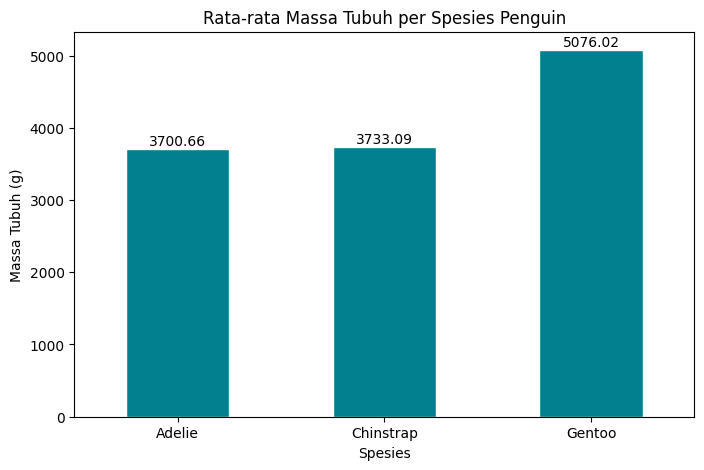

In [53]:
avg_by_species = df.groupby('species')['body_mass_g'].mean()

plt.figure(figsize=(8, 5))
avg_by_species.plot(
    kind='bar',
    color='#028090',
    edgecolor='white'
)

plt.title('Rata-rata Massa Tubuh per Spesies Penguin')
plt.xlabel('Spesies')
plt.ylabel('Massa Tubuh (g)')
plt.xticks(rotation=0)

# Label nilai
for i, v in enumerate(avg_by_species):
    plt.text(i, v + 50, f'{v:.2f}', ha='center') # Menyesuaikan offset label

plt.show()

# Analisis Grafik 1 — Bar Chart

**What?** Bagan batang menunjukkan bahwa penguin Adelie memiliki massa tubuh rata-rata **3700.66g**, Chinstrap **3733.09g**, dan Gentoo jauh lebih besar dengan rata-rata **5076.02g**.

**So what?** Perbedaan massa tubuh yang signifikan ini menunjukkan adaptasi ekologis dan evolusi yang berbeda antar spesies, yang dapat memengaruhi kebutuhan hidup dan kerentanan mereka.

**Now what?** Eksplorasi lebih lanjut dapat meneliti korelasi massa tubuh dengan ciri fisik lain (misalnya, ukuran paruh/sirip) atau distribusi geografis untuk memahami variasi ini.

/tmp/ipykernel_2886/3676401143.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Spesies', loc='upper right')


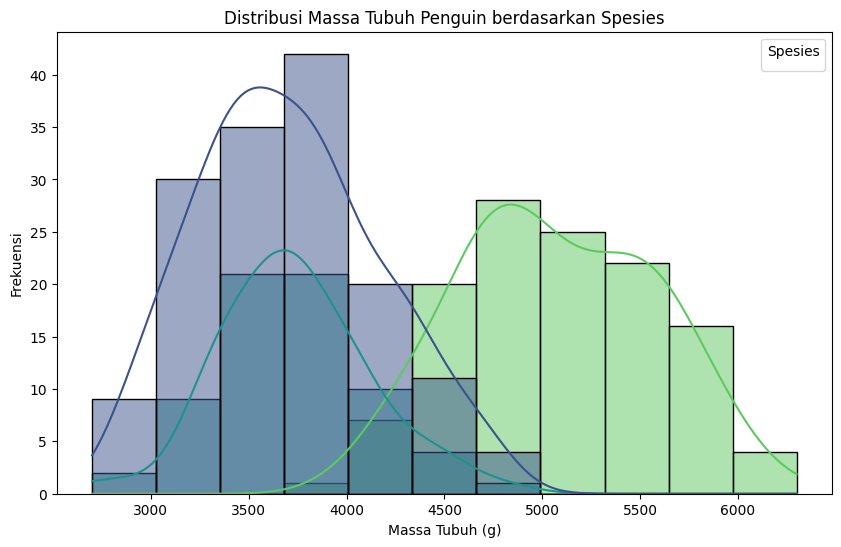

In [54]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='body_mass_g',
    hue='species',
    kde=True,
    palette='viridis'
)

plt.title('Distribusi Massa Tubuh Penguin berdasarkan Spesies')
plt.xlabel('Massa Tubuh (g)')
plt.ylabel('Frekuensi')
plt.legend(title='Spesies', loc='upper right')
plt.show()

# Analisis Grafik 2 — Histogram

**What?** Histogram menunjukkan bahwa penguin Adelie dan Chinstrap memiliki massa tubuh rata-rata yang lebih rendah (sekitar **3500-4000g**), sedangkan penguin Gentoo jauh lebih besar dengan massa tubuh bergeser ke **4500-6000g**.

**So what?** Perbedaan distribusi ini menegaskan bahwa Gentoo secara konsisten lebih besar, mencerminkan adaptasi spesies dan perbedaan ekologis.

**Now what?** Eksplorasi lebih lanjut dapat menyelidiki dimorfisme seksual atau variasi massa tubuh berdasarkan pulau.:

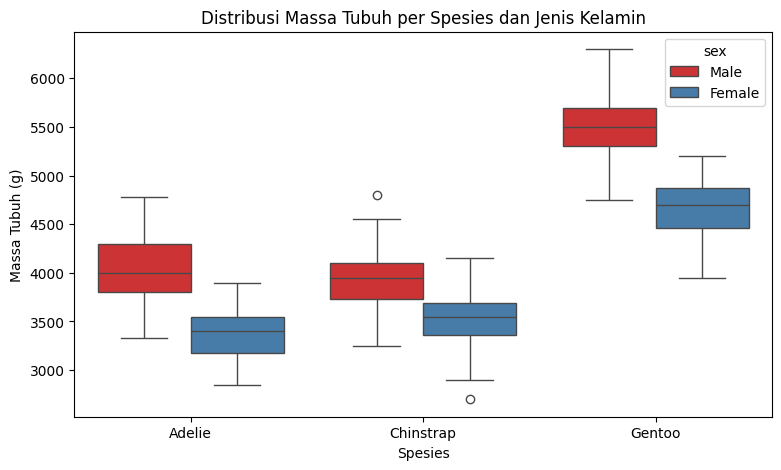

In [55]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='species',
    y='body_mass_g',
    hue='sex',
    palette='Set1'
)

plt.title('Distribusi Massa Tubuh per Spesies dan Jenis Kelamin')
plt.xlabel('Spesies')
plt.ylabel('Massa Tubuh (g)')
plt.show()

# Analisis Grafik 3 — Boxplot

**What?** Boxplot ini menunjukkan bahwa jantan (biru) umumnya memiliki massa tubuh lebih besar dari betina (oranye) di ketiga spesies. Contohnya, Gentoo jantan median ~**5500g** vs betina ~**4800g**. Adelie dan Chinstrap juga menunjukkan jantan di atas **3700g** dan betina di bawahnya.

**So what?** Visualisasi ini mengkonfirmasi dimorfisme seksual massa tubuh antar spesies. Jantan yang lebih besar adalah karakteristik umum yang memengaruhi reproduksi, mencari makan, dan dinamika sosial.

**Now what?** Selanjutnya, kita dapat mengukur perbedaan median massa tubuh per jenis kelamin, melakukan tes statistik untuk signifikansi dimorfisme, dan mengeksplorasi dimorfisme pada pengukuran fisik lain.

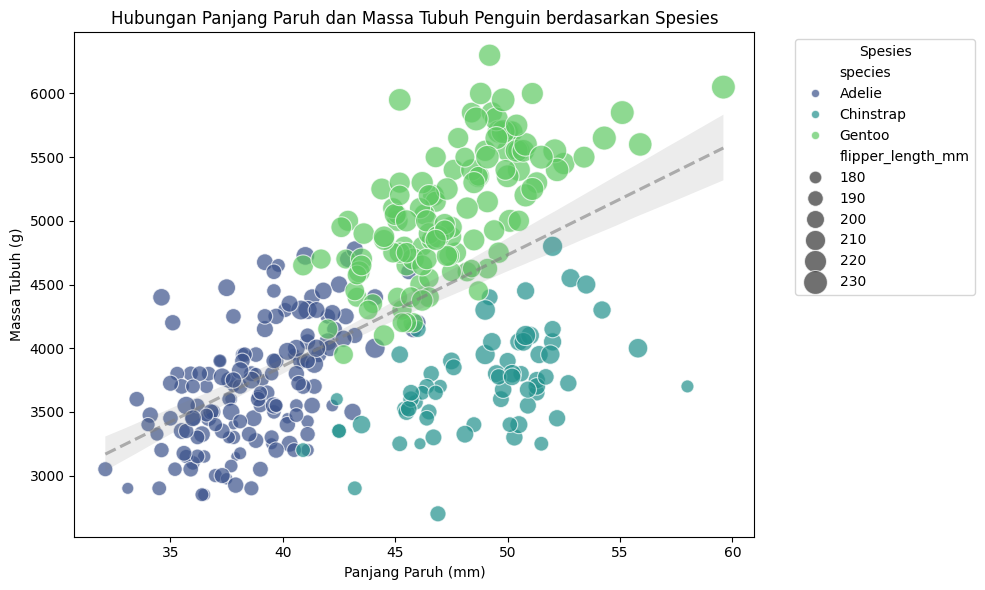

In [56]:

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='bill_length_mm',
    y='body_mass_g',
    hue='species',
    size='flipper_length_mm',
    sizes=(50, 300),
    palette='viridis',
    alpha=0.7
)

sns.regplot(
    data=df,
    x='bill_length_mm',
    y='body_mass_g',
    scatter=False,
    color='gray',
    line_kws={'linestyle': '--', 'alpha': 0.6}
)

plt.title('Hubungan Panjang Paruh dan Massa Tubuh Penguin berdasarkan Spesies')
plt.xlabel('Panjang Paruh (mm)')
plt.ylabel('Massa Tubuh (g)')
plt.legend(title='Spesies', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Analisis Grafik 4 — Scatter Plot

**What?** Diagram pencar menunjukkan korelasi positif antara panjang paruh dan massa tubuh penguin, dengan kluster spesies yang berbeda. Gentoo memiliki paruh terpanjang dan massa tubuh terbesar. Adelie dan Chinstrap menempati rentang yang lebih kecil. Garis regresi menunjukkan tren positif secara keseluruhan.

**So What?** Plot ini mengungkapkan bahwa panjang paruh dan massa tubuh adalah pengidentifikasi kunci spesies. Korelasi positif menunjukkan bahwa seiring bertambahnya ukuran penguin, panjang paruh juga cenderung meningkat, meskipun bervariasi antar spesies.

**Now What?** Kita dapat menyesuaikan garis regresi terpisah untuk setiap spesies guna menganalisis hubungan unik panjang paruh dan massa tubuh dalam setiap kelompok, untuk mengidentifikasi perbedaan pola pertumbuhan.

/tmp/ipykernel_2886/2045278326.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='Spesies', loc='upper right')
/tmp/ipykernel_2886/2045278326.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


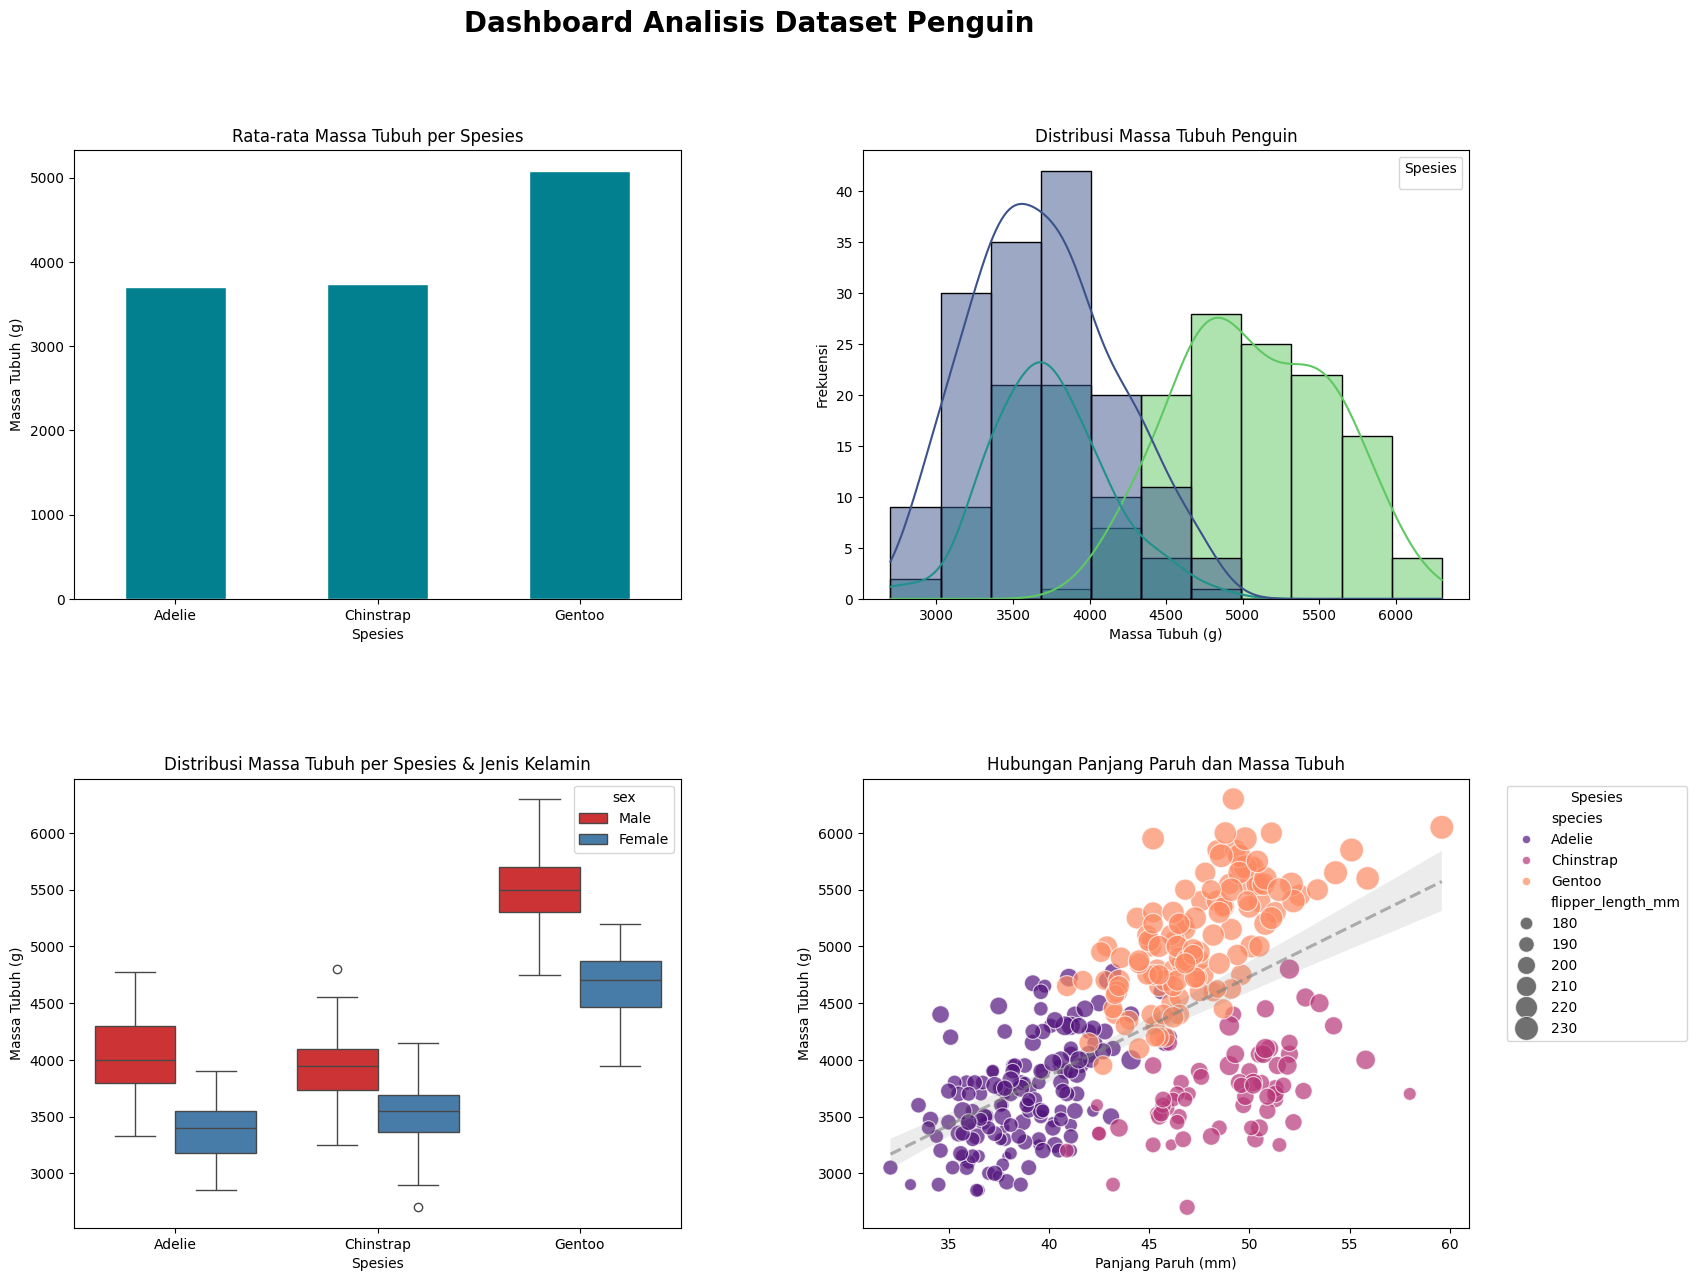

Dashboard tersimpan sebagai dashboard_penguins.png


In [57]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Dashboard Analisis Dataset Penguin', fontsize=20, fontweight='bold')

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# 1. Bar Chart: Rata-rata Massa Tubuh per Spesies
avg_by_species = df.groupby('species')['body_mass_g'].mean()
avg_by_species.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')
ax1.set_title('Rata-rata Massa Tubuh per Spesies')
ax1.set_xlabel('Spesies')
ax1.set_ylabel('Massa Tubuh (g)')
ax1.tick_params(axis='x', rotation=0)

# 2. Histogram: Distribusi Massa Tubuh berdasarkan Spesies
sns.histplot(data=df, x='body_mass_g', hue='species', kde=True, palette='viridis', ax=ax2)
ax2.set_title('Distribusi Massa Tubuh Penguin')
ax2.set_xlabel('Massa Tubuh (g)')
ax2.set_ylabel('Frekuensi')
ax2.legend(title='Spesies', loc='upper right')

# 3. Boxplot: Distribusi Massa Tubuh per Spesies & Jenis Kelamin
sns.boxplot(data=df, x='species', y='body_mass_g', hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Massa Tubuh per Spesies & Jenis Kelamin')
ax3.set_xlabel('Spesies')
ax3.set_ylabel('Massa Tubuh (g)')

# 4. Scatter Plot: Hubungan Panjang Paruh dan Massa Tubuh
sns.scatterplot(
    data=df,
    x='bill_length_mm',
    y='body_mass_g',
    hue='species',
    size='flipper_length_mm',
    sizes=(50, 300),
    palette='magma',
    alpha=0.7,
    ax=ax4
)
sns.regplot(data=df, x='bill_length_mm', y='body_mass_g', scatter=False, color='gray', line_kws={'linestyle': '--', 'alpha': 0.6}, ax=ax4)
ax4.set_title('Hubungan Panjang Paruh dan Massa Tubuh')
ax4.set_xlabel('Panjang Paruh (mm)')
ax4.set_ylabel('Massa Tubuh (g)')
ax4.legend(title='Spesies', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('dashboard_penguins.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard tersimpan sebagai dashboard_penguins.png")